<a href="https://colab.research.google.com/github/fpinell/hands_on_python_for_ds/blob/main/notebooks/phd/2026/Lecture_3_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 3 — Supervised Learning


- ### PhD IMT School for advanced studies Lucca


#### Fabio Pinelli
<a href="mailto:fabio.pinelli@imtlucca.it">fabio.pinelli@imtlucca.it</a><br/>
IMT School for Advanced Studies Lucca<br/>
2025/2026<br/>
May, 14 2026

# Today lesson

- How to organize a ML project and the steps you need to perform
- Regression
- Classification

... and some scikit-learn functionalities to authomatize the ML process.

# Taxonomy of ML

-  Roughly speaking there are two main **categories** of ML tasks:

    1.  **Supervised Learning**: Given a set of **labeled** examples, **predict** the labels of _new and unseen_ examples
    2.  **Unsupervised Learning**: Given a set of examples, **find structure** in the data (e.g., _clusters_, _subspaces_, _manifolds_)

## Supervised learning
The main difference between **Regression** and **Classification** algorithms that:
- **Regression** algorithms are used to predict the _continuous values_ such as price, salary, age, etc. and
- **Classification** algorithms are used to predict/classify the _discrete values_ such as Male or Female, True or False, Spam or Not Spam, etc.



# Check list for a Machine Learning project

1. Understand the problem.
2. Get the data.
3. Discover and visualize the data to gain insights.
4. Prepare the data for Machine Learning algorithms.
  - split on training and test
  - handling missing values
  - categorical values
  - scaling
  - etc.
5. Compare different models, choose the best and train it.
6. Fine-tune your model.
7. Present your solution.
  - stakeholder
  - paper
  - supervisor
  - etc.



#### Scikit API introduction

- Consinstency: All objects share a consistent and simple interface
  + Estimators:
    - Any object that can estimate some parameters based on a dataset
is called an _estimator_
    - It uses the fit() and it takes only the dataset as parameters, the others are considered hyperparameters.
  + Transformers: Some estimators can transform the dataset.
    - transform() method with the dataset to transform as a parameter.
    - fit_transform() to perform both operation at once (more quick)
  + Predictors: estimators that make predictions
    - predict() method that takes a dataset of new instances and returns a dataset of corresponding predictions.
    - score() to measure the quality of the predictions
- Inspection --> two types of access to relevant information
  + All the estimator’s **hyperparameters** are accessible directly via **public
instance variables**
  + all the estimator’s **learned** parameters are also accessible via public instance variables with an **underscore suffix**
- Nonproliferation of classes
  +  Datasets are represented as NumPy arrays or SciPy sparse matrices, instead of homemade classes
- Composition: Create pipelines
- Sensible defaults: scikit provides reasonable default values for most
parameters, making it easy to create a baseline working system quickly

## Understand the problem.

### A regression  problem

We load a dataset of rental listings in Milan (`rentals_milan.csv`), enriched with per-neighborhood features from `zones_milan.csv` (distance to the Duomo, average income, public-transport score). The target is the **monthly rent in €**, a *continuous* value, so this is a **regression** task.

The data is intentionally messy: prices like `"€ 950"`, mixed date formats, inconsistent casing in `neighborhood` and `furnishing`, the `floor` column mixes integers with strings like `"first"`, `"ground floor"`, `"5th"`. Part of the work is cleaning it.


In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import pandas as pd
import os



# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

import seaborn as sns


# Where to save the figures
PROJECT_ROOT_DIR = "."
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images")
os.makedirs(IMAGES_PATH, exist_ok=True)

# from google.colab import drive
# drive.mount('/content/drive')

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## Get the data

We have two CSVs in the repo's `data/` folder:
- `rentals_milan.csv` — one row per listing
- `zones_milan.csv` — one row per neighborhood with `distance_duomo_km`, `avg_income_eur`, `transport_score`

We will join them on the (normalized) neighborhood name.

In Colab:
``` python
from google.colab import drive
drive.mount('/content/drive')
```


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import re, pathlib

# Locate the data directory (works locally from the repo, or on Colab)
candidate_dirs = [
    pathlib.Path('data'),
    pathlib.Path('../../../data'),
    pathlib.Path('/content/drive/Shareddrives/phd_hands_on/data/'),
]
DATA_DIR = next(p for p in candidate_dirs if (p / 'rentals_milan.csv').exists())

rentals = pd.read_csv(DATA_DIR / 'rentals_milan.csv')
zones   = pd.read_csv(DATA_DIR / 'zones_milan.csv')

# --- Minimal type cleanup so describe()/hist() work ---
# 1) price: strip euro sign, cast to float
rentals['price'] = (rentals['price'].astype(str)
                                   .str.replace('€', '', regex=False)
                                   .str.replace(',', '.', regex=False)
                                   .str.strip()
                                   .astype(float))

# 2) floor: "first", "5th", "ground floor", "3" -> int
def _parse_floor(x):
    if pd.isna(x): return np.nan
    s = str(x).lower().strip()
    if 'ground' in s: return 0
    if 'first' in s: return 1
    m = re.search(r'\d+', s)
    return float(m.group()) if m else np.nan
rentals['floor'] = rentals['floor'].apply(_parse_floor)

# 3) neighborhood: normalize casing/whitespace, drop optional "Zone " prefix
def _norm_n(s):
    if pd.isna(s): return s
    return re.sub(r'^zone\s+', '', str(s).strip().lower())
rentals['neighborhood'] = rentals['neighborhood'].apply(_norm_n)
zones['neighborhood']   = zones['neighborhood'].apply(_norm_n)

# 4) furnishing & heating: normalize spellings
def _norm_furn(x):
    if pd.isna(x): return x
    s = str(x).lower().strip().rstrip('.')
    if 'partly' in s or 'partial' in s: return 'partly furnished'
    if s.startswith('un'): return 'unfurnished'
    if 'furn' in s: return 'furnished'
    return s
rentals['furnishing'] = rentals['furnishing'].apply(_norm_furn)
rentals['heating'] = (rentals['heating'].astype(str).str.lower().str.strip()
                       .replace({'hp': 'heat pump', 'nan': np.nan}))

# 6) sqm: some rows contain strings like "76 sqm" — strip non-digits
rentals['sqm'] = (rentals['sqm'].astype(str)
                                .str.extract(r'(\d+(?:\.\d+)?)')[0]
                                .astype(float))

# 5) Join in the per-neighborhood features
rentals = rentals.merge(zones, on='neighborhood', how='left')


In [4]:
rentals.head()

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,...,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description,distance_duomo_km,avg_income_eur,transport_score
0,ML-2025-02054,07/01/2025,corvetto,900.0,52.0,3,2,1,6.0,True,...,E,1996.0,M3,170.0,1,temporary,"Two-bedroom, with elevator, near metro M3.",5.5,30000,7
1,ML-2025-01838,2024-10-04,porta garibaldi,950.0,44.0,3,3,1,1.0,False,...,NaN,NaN,NaN,NaN,1,temporary,"Two-bedroom, in historic building, near metro M5.",2.0,52000,9
2,ML-2025-00514,2025-02-17,quarto oggiaro,850.0,88.0,4,3,1,2.0,False,...,NaN,1932.0,NaN,250.0,1,student,"Apartment, in historic building, near metro M3.",9.0,28000,5
3,ML-2025-00778,2025-01-23,de angeli,1950.0,93.0,4,4,1,5.0,True,...,A,2020.0,M1,190.0,1,temporary,"Apartment, recently built, with elevator, near...",4.0,41000,8
4,ML-2025-00803,2024-10-07,sempione,2000.0,73.0,2,1,1,4.0,True,...,E,1951.0,M5,270.0,3,4+4,"One-bedroom, with elevator, near metro M5.",2.0,43000,8


In [5]:
print('N. of rows: {}'.format(rentals.shape[0]))
print('N. of columns: {}'.format(rentals.shape[1]))
print('The columns contained in our first dataframe are:\n{}'.format(
    ',\n'.join('{}. {}'.format(i, c) for i, c in enumerate(rentals.columns))
))

N. of rows: 2513
N. of columns: 22
The columns contained in our first dataframe are:
0. id,
1. listing_date,
2. neighborhood,
3. price,
4. sqm,
5. rooms,
6. bedrooms,
7. bathrooms,
8. floor,
9. elevator,
10. furnishing,
11. heating,
12. energy_class,
13. year_built,
14. nearest_metro,
15. condo_fees,
16. deposit_months,
17. contract_type,
18. description,
19. distance_duomo_km,
20. avg_income_eur,
21. transport_score


In [6]:
rentals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2513 entries, 0 to 2512
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2513 non-null   object 
 1   listing_date       2513 non-null   object 
 2   neighborhood       2513 non-null   object 
 3   price              2513 non-null   float64
 4   sqm                2513 non-null   float64
 5   rooms              2513 non-null   int64  
 6   bedrooms           2513 non-null   int64  
 7   bathrooms          2513 non-null   int64  
 8   floor              2437 non-null   float64
 9   elevator           2513 non-null   bool   
 10  furnishing         2513 non-null   object 
 11  heating            2513 non-null   object 
 12  energy_class       1912 non-null   object 
 13  year_built         2331 non-null   float64
 14  nearest_metro      2187 non-null   object 
 15  condo_fees         2312 non-null   float64
 16  deposit_months     2513 

We expect output similar to:

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: ~2513 entries
Data columns include:
 #   Column              Dtype
---  ------              -----
 0   id                  object
 1   listing_date        object       <-- mixed date formats
 2   neighborhood        object
 3   price               float64
 4   sqm                 int64
 5   rooms               int64
 6   bedrooms            int64
 7   bathrooms           int64
 8   floor               float64      <-- cleaned from messy strings
 9   elevator            bool
 10  furnishing          object
 11  heating             object
 12  energy_class        object       <-- some NaN
 13  year_built          float64      <-- some NaN
 14  nearest_metro       object       <-- some NaN
 15  condo_fees          float64      <-- some NaN
 16  deposit_months      int64
 17  contract_type       object
 18  description         object
 19  distance_duomo_km   float64      <-- from zones
 20  avg_income_eur      int64        <-- from zones
 21  transport_score     int64        <-- from zones
```


Several columns present peculiarities:

- `year_built`, `condo_fees`, `energy_class`, `nearest_metro` — contain **missing values**
- `listing_date` — contains **mixed date formats** that we'll skip for modelling
- `nearest_metro`, `furnishing`, `heating`, `energy_class`, `contract_type`, `neighborhood` — are **categorical**

Do you know how to deal with these?


In [7]:
rentals["neighborhood"].value_counts()

,count
neighborhood,
città studi,167
navigli,161
lambrate,136
nolo,135
bicocca,135
isola,126
porta romana,125
porta venezia,123
lorenteggio,121


In [8]:
rentals

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,...,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description,distance_duomo_km,avg_income_eur,transport_score
0,ML-2025-02054,07/01/2025,corvetto,900.0,52.0,3,2,1,6.0,True,...,E,1996.0,M3,170.0,1,temporary,"Two-bedroom, with elevator, near metro M3.",5.5,30000,7
1,ML-2025-01838,2024-10-04,porta garibaldi,950.0,44.0,3,3,1,1.0,False,...,NaN,NaN,NaN,NaN,1,temporary,"Two-bedroom, in historic building, near metro M5.",2.0,52000,9
2,ML-2025-00514,2025-02-17,quarto oggiaro,850.0,88.0,4,3,1,2.0,False,...,NaN,1932.0,NaN,250.0,1,student,"Apartment, in historic building, near metro M3.",9.0,28000,5
3,ML-2025-00778,2025-01-23,de angeli,1950.0,93.0,4,4,1,5.0,True,...,A,2020.0,M1,190.0,1,temporary,"Apartment, recently built, with elevator, near...",4.0,41000,8
4,ML-2025-00803,2024-10-07,sempione,2000.0,73.0,2,1,1,4.0,True,...,E,1951.0,M5,270.0,3,4+4,"One-bedroom, with elevator, near metro M5.",2.0,43000,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2508,ML-2025-00776,2024-11-30,porta romana,1850.0,76.0,3,2,2,3.0,False,...,G,1914.0,M3,70.0,3,3+2,NaN,2.2,45000,8
2509,ML-2025-00692,25/11/2024,nolo,1950.0,100.0,4,3,1,8.0,True,...,A,2017.0,M1,140.0,1,temporary,"Apartment, recently built, with elevator, near...",4.0,38000,7
2510,ML-2025-02376,24 November 2024,isola,1850.0,81.0,3,2,2,8.0,True,...,F,1987.0,M5,130.0,2,3+2,NaN,3.0,40000,8
2511,ML-2025-01927,07/03/2025,sempione,160.0,70.0,3,2,1,2.0,False,...,E,1915.0,M5,NaN,1,temporary,"Two-bedroom, in historic building, near metro M5.",2.0,43000,8


In [9]:
# Drop listings with no price (our target) — analog to dropping odd categories.
rentals = rentals[rentals["price"].notna()].copy()

In [10]:
rentals.shape

(2513, 22)

In [11]:
rentals.reset_index(inplace=True, drop=True)

In [12]:
rentals.describe()

,price,sqm,rooms,bedrooms,bathrooms,floor,year_built,condo_fees,deposit_months,distance_duomo_km,avg_income_eur,transport_score
count,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2437.000000,2331.000000,2312.000000,2513.000000,2513.000000,2513.000000,2513.000000
mean,1451.602865,71.035018,3.023876,2.222045,1.353760,3.328272,1972.305877,173.010381,2.126542,3.942579,40942.697971,7.312376
std,873.213628,29.599092,1.216030,1.121606,0.480722,2.117774,39.115505,72.264023,0.793023,2.252043,8737.314474,1.157533
min,80.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1019.000000,50.000000,-2.000000,0.400000,28000.000000,5.000000
25%,900.000000,50.000000,2.000000,1.000000,1.000000,2.000000,1944.000000,110.000000,1.000000,2.200000,35000.000000,7.000000
50%,1300.000000,66.000000,3.000000,2.000000,1.000000,3.000000,1980.000000,170.000000,2.000000,3.500000,40000.000000,8.000000
75%,1800.000000,86.000000,4.000000,3.000000,2.000000,5.000000,2002.000000,230.000000,3.000000,6.000000,45000.000000,8.000000
max,14902.000000,250.000000,6.000000,6.000000,4.000000,17.000000,2030.000000,320.000000,3.000000,9.000000,75000.000000,9.000000


## Explore the data and visualize

It helps to identify peculierities in our datasets, and if we -- data scientist -- we need to take into account some specificity that we highlight through some simple visualization plots.

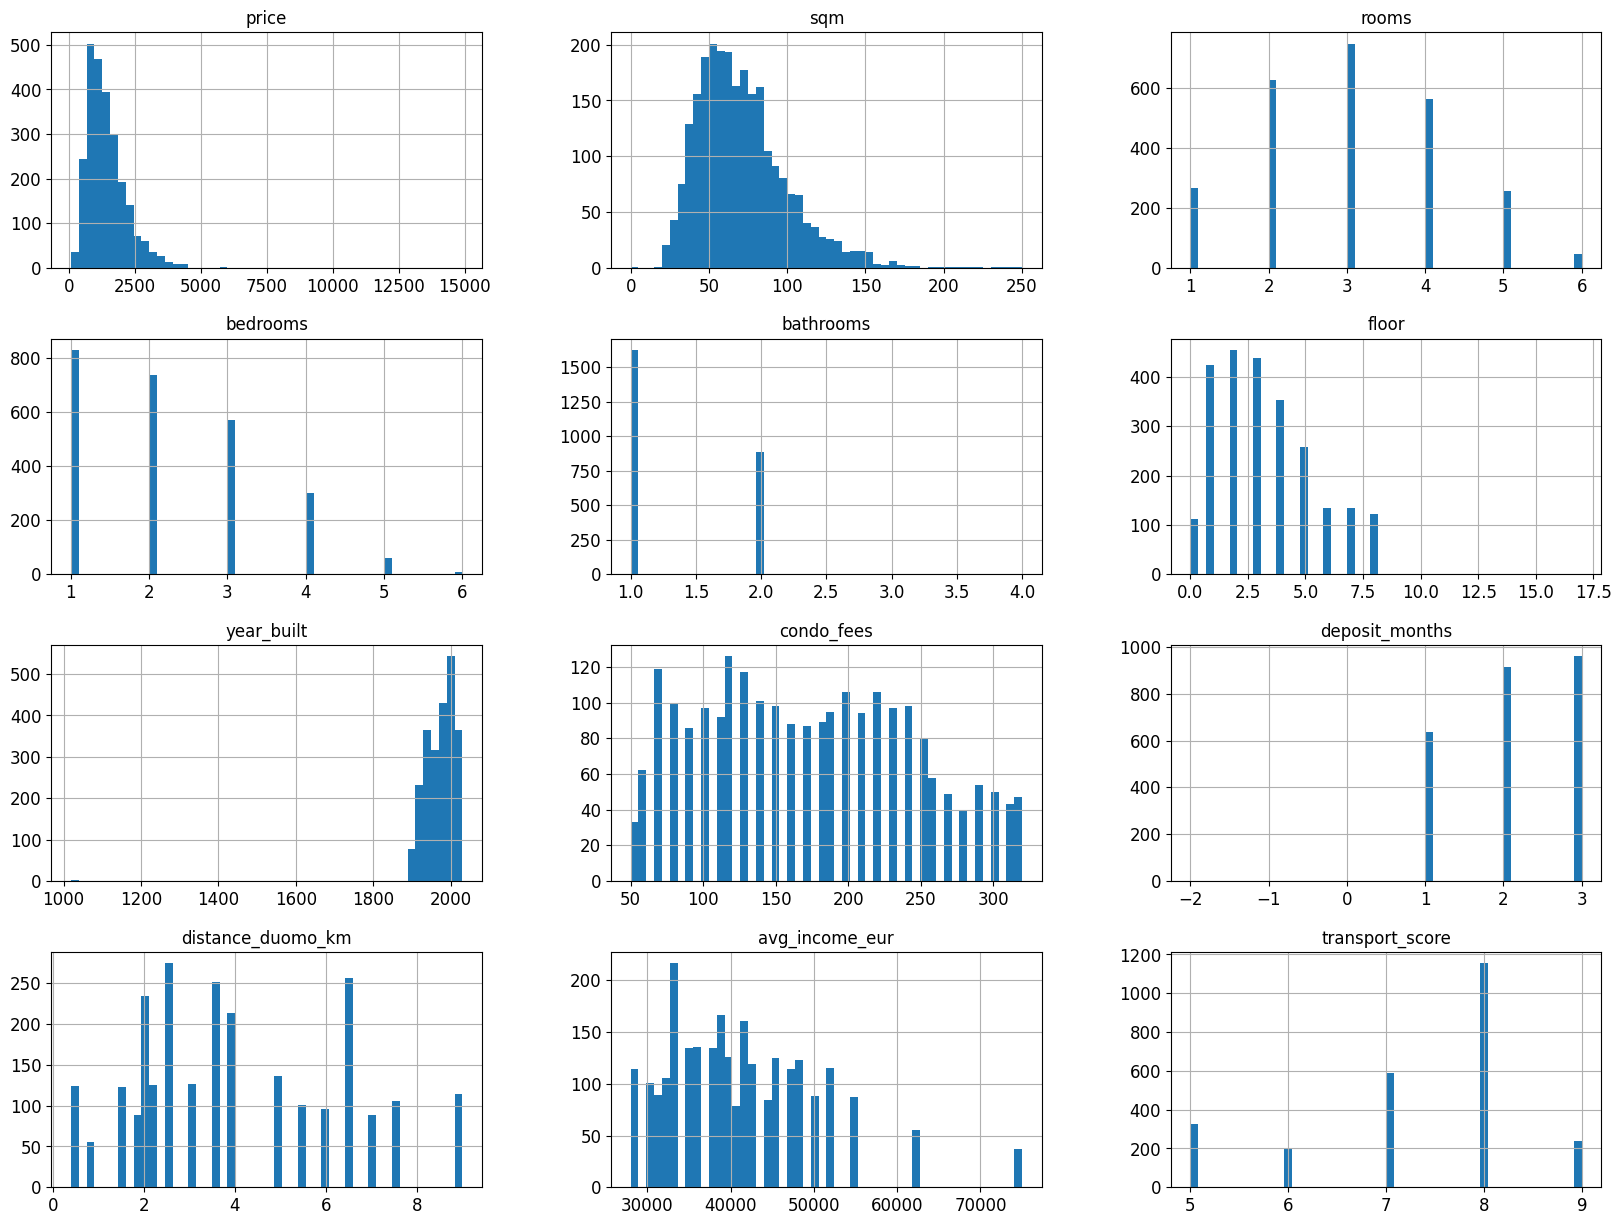

In [13]:
'''
We call hist() function defined for pandas dataframes.
It's a Pandas function that generates histograms for numerical features
'''

rentals.hist(bins=50, figsize=(20, 15))
plt.show()

### Some comments on the data

1. The **price** distribution is heavily right-skewed: most rents cluster between 800 and 2000 €, but there is a long tail of expensive listings. ML algorithms can struggle with tail-heavy targets.
2. **sqm**, **condo_fees** are also right-skewed.
3. **avg_income_eur** and **distance_duomo_km** were joined from the zone table — they take only ~20 distinct values (one per neighborhood).
4. The features are on very different scales (rooms in single digits, prices in thousands, income in tens of thousands). We will need to **scale** them before fitting linear models.


We discussed some other functions to easily and quickly visualize the data of our dataframes.

- Correlation Matrix
- Seaborn pairplots
- KDE

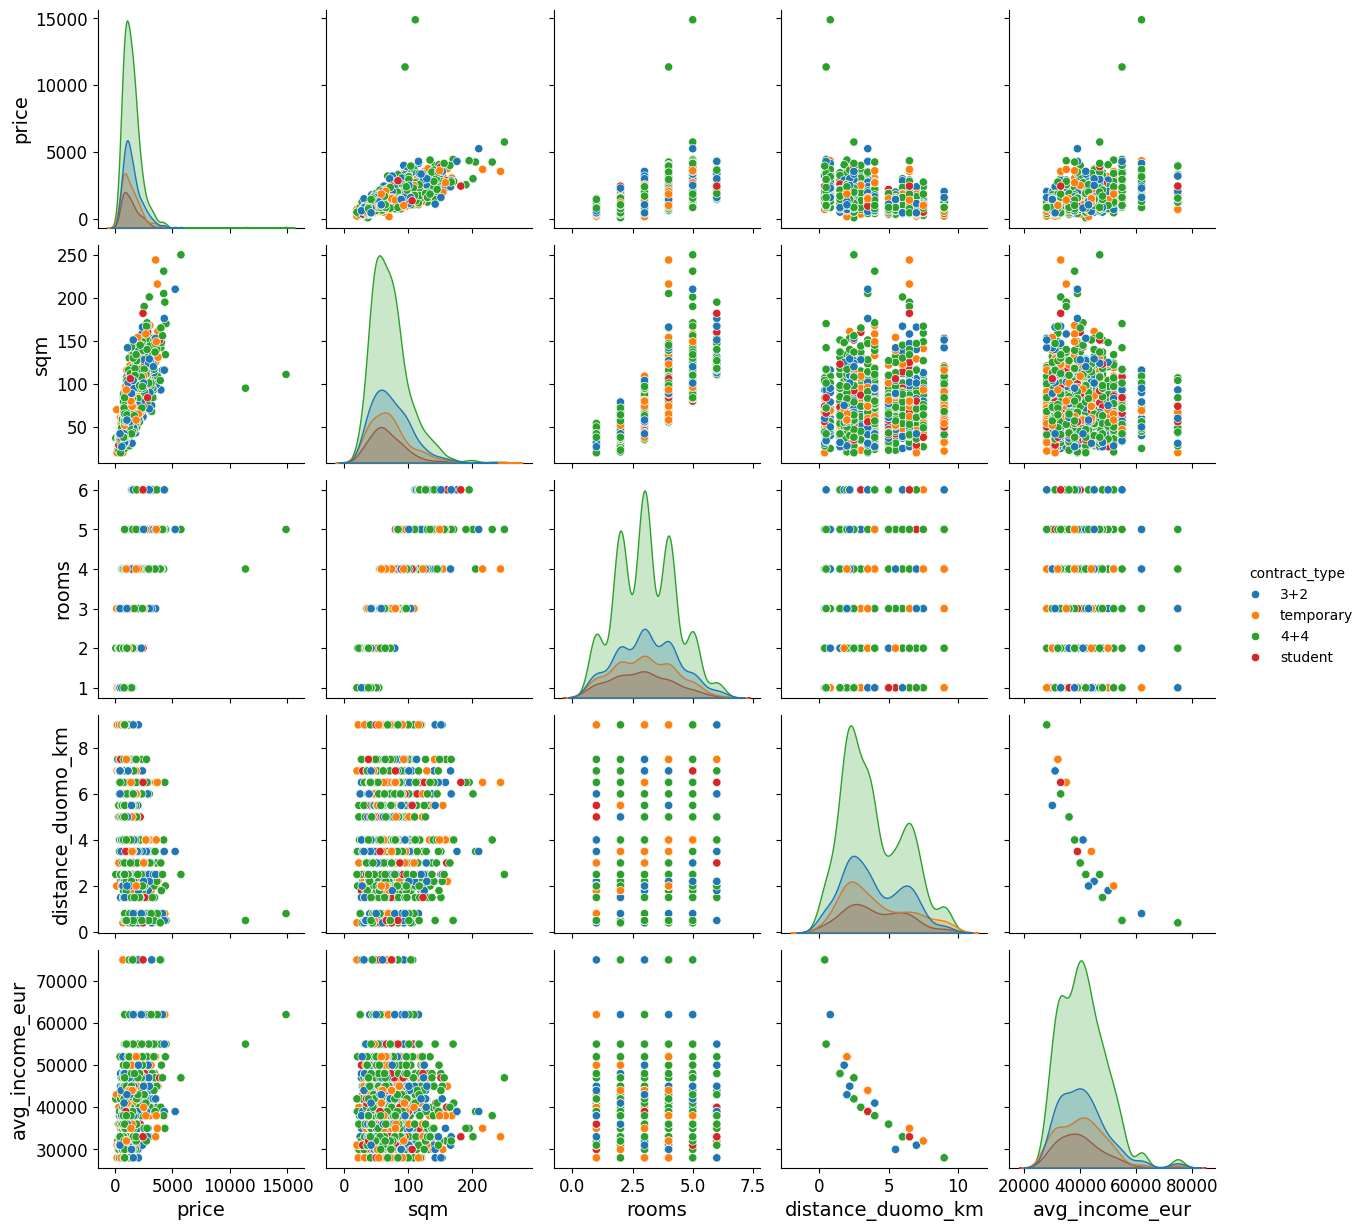

In [14]:
# tipically we group by the classes when we deal with a classification task
# In any case, we could see if there are any interesting pattern emerging, or differences in the distributions.
plot = True
if plot:
    cols = ['price', 'sqm', 'rooms', 'distance_duomo_km', 'avg_income_eur', 'contract_type']
    _ = sns.pairplot(rentals[cols].sample(min(1500, len(rentals)), random_state=42),
                     hue='contract_type')

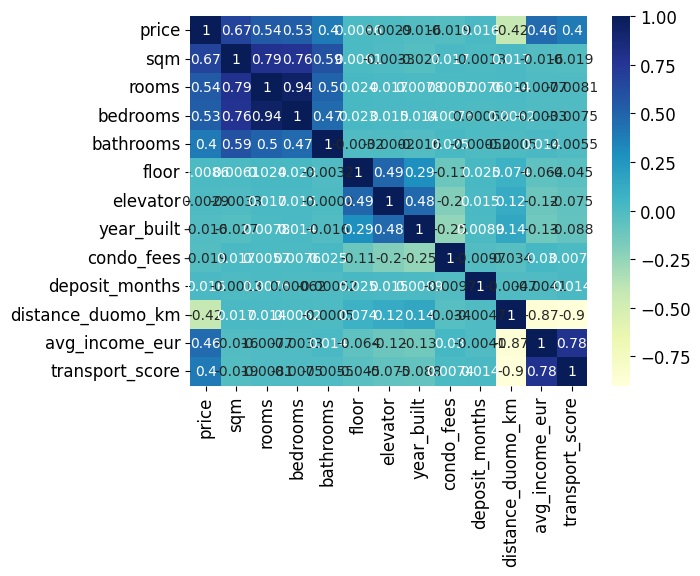

In [15]:
'''
Another check that we could do is to verify if features have strong correlation among them or with the target variable
'''

corr = rentals.corr('pearson', numeric_only=True)
_ = sns.heatmap(corr, annot=True, cmap="YlGnBu")

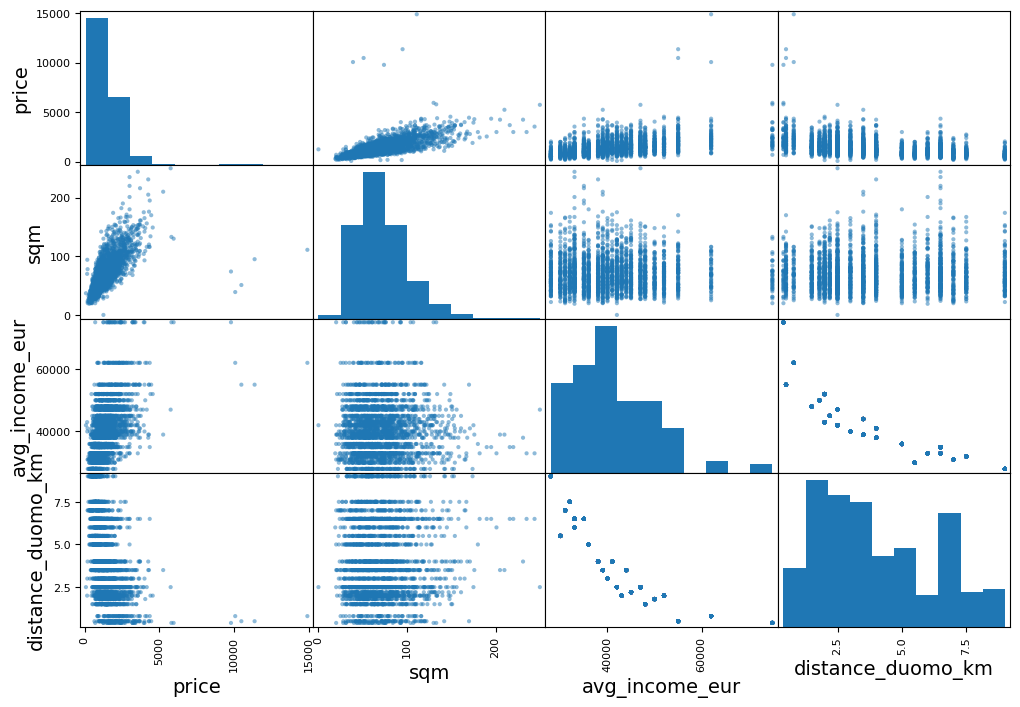

In [16]:
from pandas.plotting import scatter_matrix
attributes = ["price", "sqm", "avg_income_eur", "distance_duomo_km"]
_ = scatter_matrix(rentals[attributes], figsize=(12, 8))

In [17]:
'''
We can check which features have a greater correlation with the target variable
'''
corr["price"].sort_values(ascending=False)

,price
price,1.000000
sqm,0.670168
rooms,0.544967
bedrooms,0.527899
avg_income_eur,0.461622
bathrooms,0.395712
transport_score,0.395029
deposit_months,0.015783
floor,0.008574
elevator,0.002950


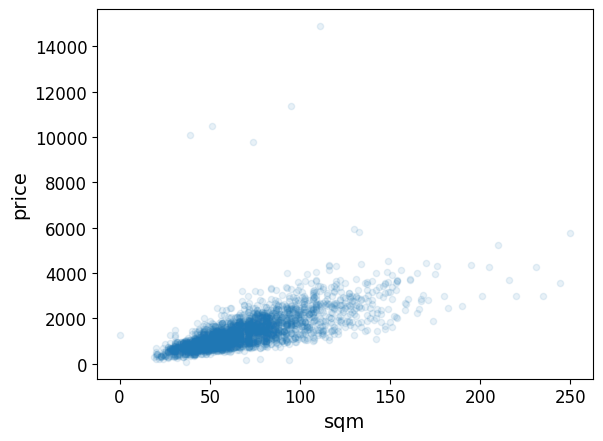

In [18]:
'''
Among the numeric features, `sqm` and `avg_income_eur` are typically the most correlated with `price`.
Let's look at the scatter for sqm vs price.

You'll likely notice some horizontal striping (round-number rents like 1000, 1500, 2000) — a real-world data artifact a data scientist must decide how to handle.
'''

_ = rentals.plot(kind='scatter', x='sqm', y='price', alpha=.1)

<Axes: xlabel='distance_duomo_km', ylabel='transport_score'>

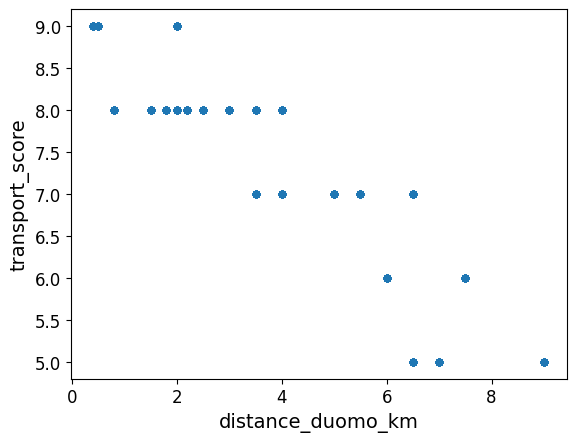

In [19]:
'''
We don't have latitude/longitude, but we do have `distance_duomo_km` and `transport_score`
from the zones table — a coarse "geography" of Milan.
'''

rentals.plot(kind="scatter", x="distance_duomo_km", y="transport_score")

<Axes: xlabel='distance_duomo_km', ylabel='transport_score'>

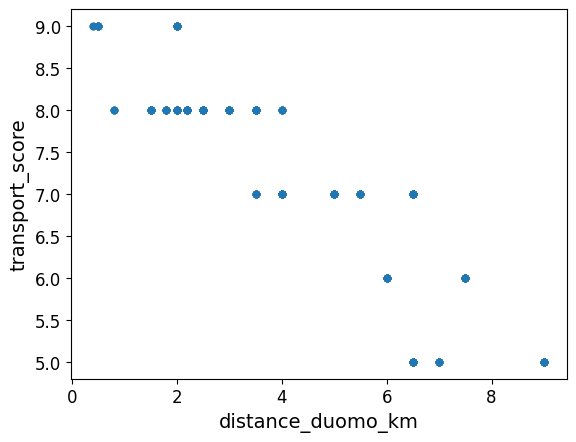

In [20]:
'''
With alpha we can see where listings concentrate: most are close to the Duomo and in
well-connected zones.
'''

rentals.plot(kind="scatter", x="distance_duomo_km", y="transport_score", alpha=0.1)

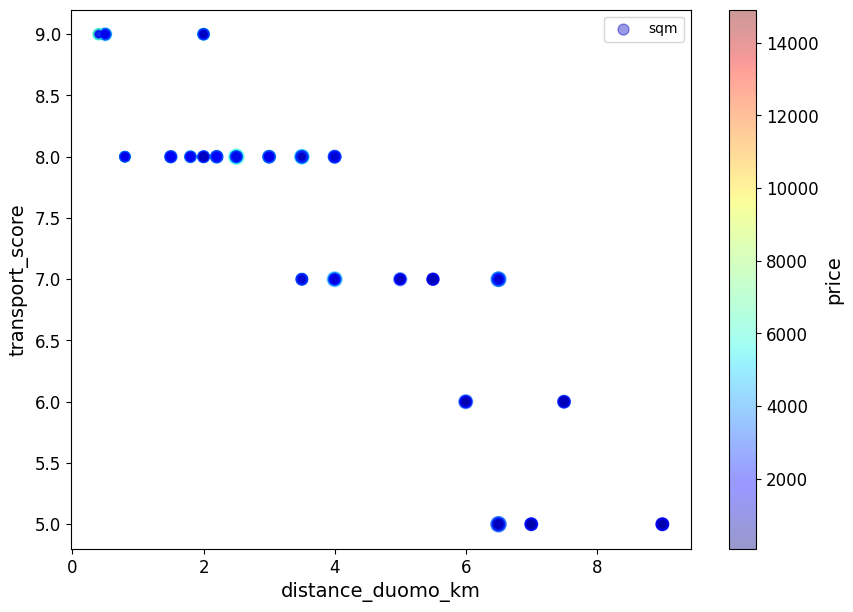

In [21]:
'''
Let's color by price and size by sqm.
Distance to the Duomo and transport quality both influence the rent.
'''

_ = rentals.plot(kind="scatter", x="distance_duomo_km", y="transport_score", alpha=0.4,
                 s=rentals["sqm"] / 2, label="sqm", figsize=(10, 7),
                 c="price", cmap=plt.get_cmap("jet"), colorbar=True,
                 sharex=False)
plt.legend()

### Better views of the zone-level geography

The scatter above is misleading: `distance_duomo_km` and `transport_score` are both *zone-level* — with ~20 neighborhoods we only get ~20 distinct (x, y) pairs and listings pile on top of each other. Below are a few plots that surface more signal.

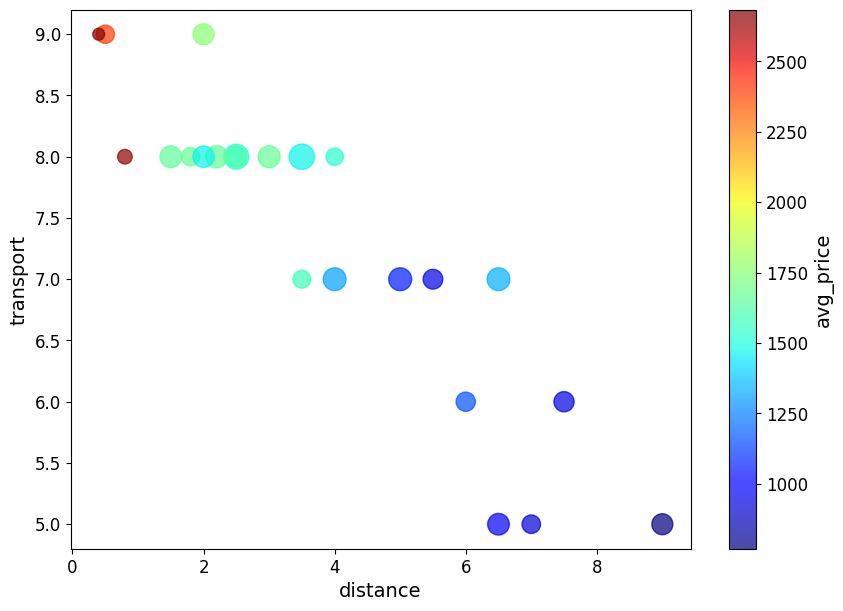

In [22]:
'''
Aggregate to one bubble per zone: position = (distance, transport),
size = number of listings (market thickness), color = average price.
'''

zone_stats = (rentals.groupby("neighborhood")
              .agg(distance=("distance_duomo_km", "first"),
                   transport=("transport_score", "first"),
                   avg_price=("price", "mean"),
                   n_listings=("price", "size"))
              .reset_index())

_ = zone_stats.plot(kind="scatter", x="distance", y="transport",
                    s=zone_stats["n_listings"] * 2, c="avg_price",
                    cmap=plt.get_cmap("jet"), colorbar=True,
                    figsize=(10, 7), alpha=0.7)

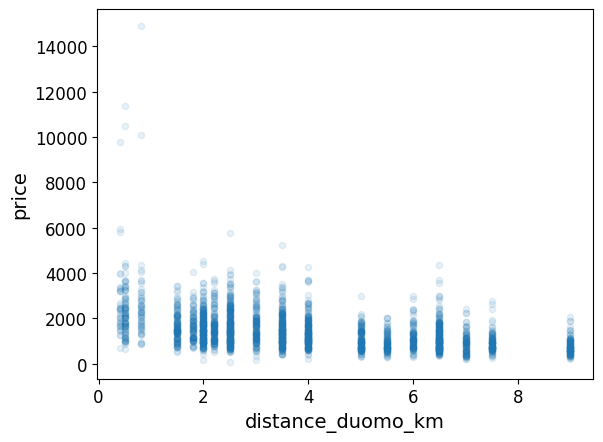

In [23]:
'''
Direct price vs distance to the Duomo: this is the actual signal we care about
for the regression task. Transport on the y-axis in the original plot was hiding it.
'''

_ = rentals.plot(kind="scatter", x="distance_duomo_km", y="price", alpha=0.1)

Text(0.5, 1.0, 'Price by neighborhood (ordered by distance from Duomo)')

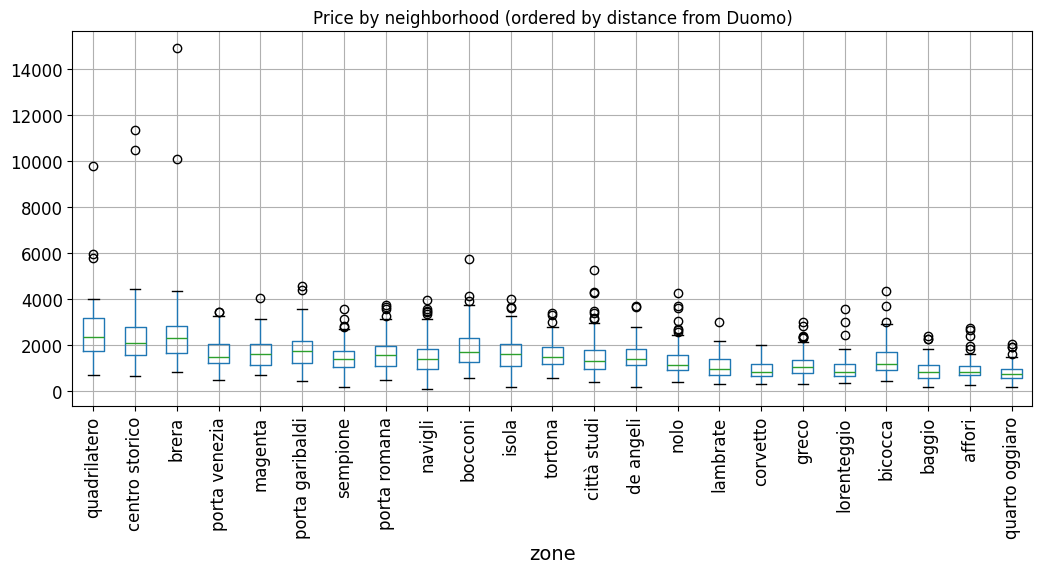

In [24]:
'''
Boxplot per zone, ordered by distance from the Duomo.
Shows price distribution and spread within each neighborhood and how it shifts
as we move away from the center: within-zone vs between-zone variance.
'''

order = (rentals.groupby("neighborhood")["distance_duomo_km"].first()
         .sort_values().index.tolist())

_ = (rentals.assign(zone=pd.Categorical(rentals["neighborhood"], categories=order, ordered=True))
     .boxplot(column="price", by="zone", rot=90, figsize=(12, 5)))
plt.suptitle("")
plt.title("Price by neighborhood (ordered by distance from Duomo)")

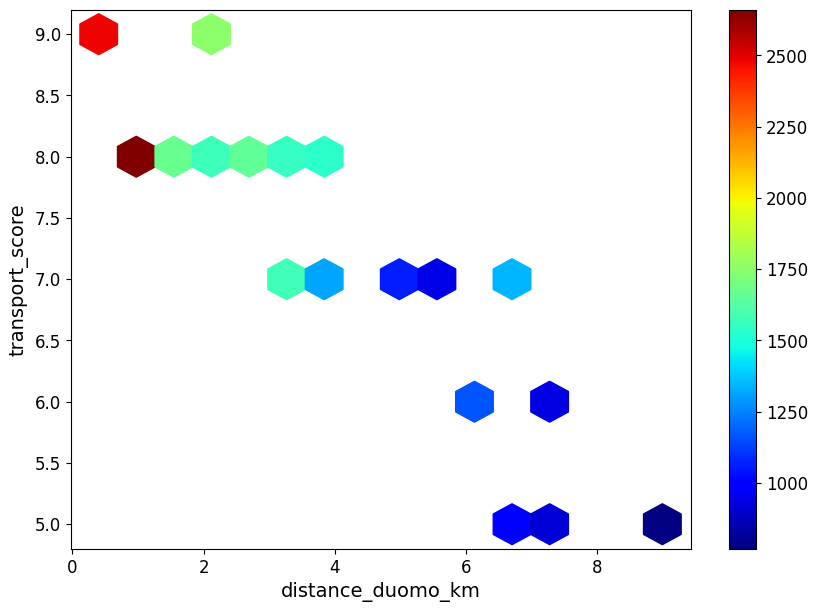

In [25]:
'''
Same axes as the original scatter, but each hex cell shows the MEAN price
of the listings falling into it. Overplotting becomes information.
'''

_ = rentals.plot(kind="hexbin", x="distance_duomo_km", y="transport_score",
                 C="price", reduce_C_function=np.mean, gridsize=15,
                 cmap="jet", figsize=(10, 7))

## Data preparation

### Split in training and test.

Scikit-learn provides to the developers a series of function that can be used to split the original dataset in training and test.

- ***__Training__*** is the set used to train our model together with the relative pipeline
- ***__Test__*** is the dataset that shouldn't be touched until the very end of the ML process. Everything needs to be "learned" from the training set (e.g. imputing value for an inputer)

In [26]:
from sklearn.model_selection import train_test_split

'''
1. random_state to get the same dataset split in different runs.
2. test_size the proportion of the dataset that we want to preserve for test, the rest is for training.
3. This is a purely random --> can introduce a significant sampling bias
'''

train_set, test_set = train_test_split(rentals, test_size=0.2, random_state=42)

In [27]:
print(train_set.shape)
print(test_set.shape)
print(rentals.shape)

(2010, 22)
(503, 22)
(2513, 22)


We can imagine that **`avg_income_eur`** (the neighborhood's average income) is an important feature to predict rent. Thus:

+ We want to avoid a sample bias between training and test.
+ Ensure that the test set is representative of the various income strata in the whole dataset.

--->  ***stratified sampling***: the population is divided into homogeneous subgroups called strata, and the right number of instances is sampled from each stratum to guarantee that the test set is representative of the overall population

In order to use `avg_income_eur` as a categorical value we need to create a new column using a special function of pandas.


In [28]:
'''
pd.cut creates bins and assigns each row to a specific bin given the intervals provided to the function.
'''

rentals["income_cat"] = pd.cut(rentals["avg_income_eur"],
                               bins=[0, 35000, 42000, 50000, np.inf],
                               labels=[1, 2, 3, 4])

In [29]:
'''
Check the frequency of the new values
'''

rentals["income_cat"].value_counts()

,count
income_cat,
2,804
1,762
3,653
4,294


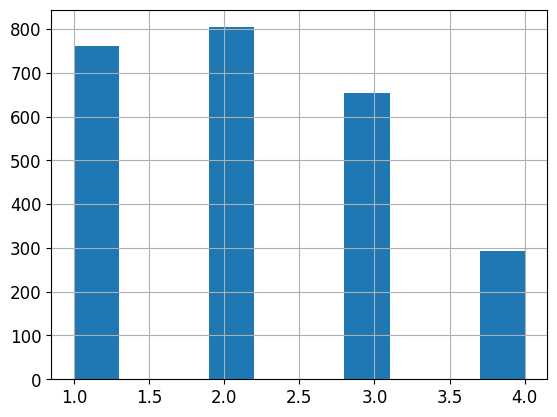

In [30]:
'''
and here the relative plot
'''
_ = rentals["income_cat"].hist()

In [31]:
'''
Now that we have a column with discrete values, it is easier to preserve the distributions between training and test set.
Scikit provides StratifiedShuffleSplit

Provides train/test indices to split data in train/test sets.

This cross-validation object is a merge of StratifiedKFold and
ShuffleSplit, which returns stratified randomized folds
'''

from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(rentals, rentals["income_cat"]):
    strat_train_set = rentals.loc[train_index]
    strat_test_set = rentals.loc[test_index]

In [32]:
'''
Let's check if the proportion of income_cat is maintained between test and training
'''
print(strat_test_set["income_cat"].value_counts() / len(strat_test_set))
print(strat_train_set["income_cat"].value_counts() / len(strat_train_set))

income_cat
2    0.320080
1    0.302187
3    0.260437
4    0.117296
Name: count, dtype: float64
income_cat
2    0.319900
1    0.303483
3    0.259701
4    0.116915
Name: count, dtype: float64


In [33]:
'''
We can compare the results with the pure random split
'''

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(rentals, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall":      income_cat_proportions(rentals),
    "Stratified":   income_cat_proportions(strat_test_set),
    "Random":       income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"]  = 100 * compare_props["Random"]     / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100
compare_props

,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.303223,0.302187,0.316103,4.247742,-0.341781
2,0.319936,0.320080,0.322068,0.666152,0.044756
3,0.259849,0.260437,0.258449,-0.538576,0.226512
4,0.116992,0.117296,0.103380,-11.634952,0.260343


In [34]:
'''
And finally we can drop the created column
'''

for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

### Feature engineering

In [35]:
'''
Another strategy to enrich the dataset is to create new features defined as combinations of existing ones.

A first attempt — inspired by the California housing example — would be ratios such as
`sqm_per_room`, `bedrooms_per_room`, or `age = 2025 - year_built`.
However, when we check the correlation with the target, these turn out to be very weak (|corr| < 0.1).

For Milan rentals, INTERACTIONS between size and location/quality signals work much better:
- sqm_x_income     = sqm * avg_income_eur     # size meets neighborhood wealth   -> |corr| ~ 0.83
- sqm_x_transport  = sqm * transport_score    # size meets transport quality     -> |corr| ~ 0.79
- rooms_x_bath     = rooms * bathrooms        # overall "capacity" of the unit   -> |corr| ~ 0.55
- age              = 2025 - year_built        # kept for didactic purposes
'''

# arithmetic combinations of existing columns
rentals["sqm_x_income"]    = rentals["sqm"]   * rentals["avg_income_eur"]
rentals["sqm_x_transport"] = rentals["sqm"]   * rentals["transport_score"]
rentals["rooms_x_bath"]    = rentals["rooms"] * rentals["bathrooms"]
rentals["age"]             = 2025 - rentals["year_built"]

In [36]:
'''
And now we can check if we found some interesting correlation with the target variable and the new ones.
'''

corr_matrix = rentals.corr(numeric_only=True)
corr_matrix["price"].sort_values(ascending=False)

,price
price,1.000000
sqm_x_income,0.833485
sqm_x_transport,0.787684
sqm,0.670168
rooms_x_bath,0.545714
rooms,0.544967
bedrooms,0.527899
avg_income_eur,0.461622
bathrooms,0.395712
transport_score,0.395029


1. **sqm_x_income** (size × neighborhood wealth) is the strongest engineered feature: it captures the idea that the *same square meter* costs more in a wealthier zone.
2. **sqm_x_transport** (size × transport quality) follows the same logic with public-transport accessibility.
3. **rooms_x_bath** acts as a proxy for the overall capacity of the unit and outperforms naive ratios like `bedrooms_per_room`.
4. **age** has weak linear correlation on its own — kept here mostly to show that not every derived feature improves the signal; some are useful only after a non-linear model.
5. The lesson: arithmetic combinations are not magic. Always *measure* the correlation against the target before committing a feature to the pipeline.

In [37]:
'''
From now on we will use the strat_train_set as DataFrame
'''

rentals = strat_train_set.drop("price", axis=1)         # drop labels for training set
rentals_labels = strat_train_set["price"].copy()        # our labels

### Data cleaning

#### Missing values

In our dataset, columns like `year_built`, `condo_fees`, `energy_class`, and `nearest_metro` contain missing values. Three classic strategies:

• Drop the rows containing missing values.
  - ``` rentals.dropna(subset=["year_built"]) ```

• Drop the whole column.

  - ``` rentals.drop("year_built", axis=1) ```

• Fill the missing values with some statistic (zero, the mean, the median, etc.).
  - ``` median = rentals["year_built"].median() ```
  - ``` rentals["year_built"].fillna(median, inplace=True) ```
  - **Important**: compute the median value on the **training set**, and use that exact value to replace missing values in the test set when you evaluate your system. Otherwise you leak information from test into training.

For this last option scikit-learn provides a class <code>SimpleImputer</code> that fits the statistic on training data and applies it consistently.

--> This allows us to perform all the *transformations* of our dataset only using Scikit-learn (numerical AND categorical, as we will see below).

In [38]:
sample_incomplete_rows = rentals[rentals.isnull().any(axis=1)].head()
sample_incomplete_rows

,id,listing_date,neighborhood,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,...,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description,distance_duomo_km,avg_income_eur,transport_score
1198,ML-2025-00227,2024-12-05,lorenteggio,56.0,2,1,1,4.0,True,partly furnished,...,E,1988.0,NaN,90.0,2,4+4,"One-bedroom, with elevator.",6.5,33000,5
2017,ML-2025-01133,2025-01-22,porta venezia,47.0,2,1,1,1.0,True,partly furnished,...,D,1992.0,NaN,170.0,2,4+4,"One-bedroom, with elevator, near metro M1.",1.5,48000,8
1824,ML-2025-00763,29/12/2024,navigli,146.0,6,5,2,7.0,True,unfurnished,...,NaN,1988.0,M2,160.0,2,4+4,"Large apartment, with elevator, near metro M2.",2.5,42000,8
1751,ML-2025-00998,2025-02-07,porta romana,42.0,2,1,1,1.0,False,furnished,...,NaN,NaN,M3,320.0,2,4+4,"One-bedroom, in historic building, near metro M3.",2.2,45000,8
1383,ML-2025-02507,24/03/2025,magenta,79.0,3,2,2,4.0,True,partly furnished,...,NaN,1992.0,M1,100.0,1,temporary,"Two-bedroom, with elevator, near metro M1.",1.8,50000,8


In [39]:
sample_incomplete_rows.dropna(subset=["year_built"])    # option 1

,id,listing_date,neighborhood,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,...,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description,distance_duomo_km,avg_income_eur,transport_score
1198,ML-2025-00227,2024-12-05,lorenteggio,56.0,2,1,1,4.0,True,partly furnished,...,E,1988.0,NaN,90.0,2,4+4,"One-bedroom, with elevator.",6.5,33000,5
2017,ML-2025-01133,2025-01-22,porta venezia,47.0,2,1,1,1.0,True,partly furnished,...,D,1992.0,NaN,170.0,2,4+4,"One-bedroom, with elevator, near metro M1.",1.5,48000,8
1824,ML-2025-00763,29/12/2024,navigli,146.0,6,5,2,7.0,True,unfurnished,...,NaN,1988.0,M2,160.0,2,4+4,"Large apartment, with elevator, near metro M2.",2.5,42000,8
1383,ML-2025-02507,24/03/2025,magenta,79.0,3,2,2,4.0,True,partly furnished,...,NaN,1992.0,M1,100.0,1,temporary,"Two-bedroom, with elevator, near metro M1.",1.8,50000,8


In [40]:
sample_incomplete_rows.drop("year_built", axis=1)       # option 2

,id,listing_date,neighborhood,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,heating,energy_class,nearest_metro,condo_fees,deposit_months,contract_type,description,distance_duomo_km,avg_income_eur,transport_score
1198,ML-2025-00227,2024-12-05,lorenteggio,56.0,2,1,1,4.0,True,partly furnished,autonomous,E,NaN,90.0,2,4+4,"One-bedroom, with elevator.",6.5,33000,5
2017,ML-2025-01133,2025-01-22,porta venezia,47.0,2,1,1,1.0,True,partly furnished,central,D,NaN,170.0,2,4+4,"One-bedroom, with elevator, near metro M1.",1.5,48000,8
1824,ML-2025-00763,29/12/2024,navigli,146.0,6,5,2,7.0,True,unfurnished,central,NaN,M2,160.0,2,4+4,"Large apartment, with elevator, near metro M2.",2.5,42000,8
1751,ML-2025-00998,2025-02-07,porta romana,42.0,2,1,1,1.0,False,furnished,heat pump,NaN,M3,320.0,2,4+4,"One-bedroom, in historic building, near metro M3.",2.2,45000,8
1383,ML-2025-02507,24/03/2025,magenta,79.0,3,2,2,4.0,True,partly furnished,autonomous,NaN,M1,100.0,1,temporary,"Two-bedroom, with elevator, near metro M1.",1.8,50000,8


In [41]:
median = rentals["year_built"].median()
print("The median of year_built is {}".format(median))
sample_incomplete_rows["year_built"].fillna(median, inplace=True)   # option 3
sample_incomplete_rows

The median of year_built is 1980.0


/tmp/ipykernel_26266/3652610351.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sample_incomplete_rows["year_built"].fillna(median, inplace=True)   # option 3


,id,listing_date,neighborhood,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,...,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description,distance_duomo_km,avg_income_eur,transport_score
1198,ML-2025-00227,2024-12-05,lorenteggio,56.0,2,1,1,4.0,True,partly furnished,...,E,1988.0,NaN,90.0,2,4+4,"One-bedroom, with elevator.",6.5,33000,5
2017,ML-2025-01133,2025-01-22,porta venezia,47.0,2,1,1,1.0,True,partly furnished,...,D,1992.0,NaN,170.0,2,4+4,"One-bedroom, with elevator, near metro M1.",1.5,48000,8
1824,ML-2025-00763,29/12/2024,navigli,146.0,6,5,2,7.0,True,unfurnished,...,NaN,1988.0,M2,160.0,2,4+4,"Large apartment, with elevator, near metro M2.",2.5,42000,8
1751,ML-2025-00998,2025-02-07,porta romana,42.0,2,1,1,1.0,False,furnished,...,NaN,1980.0,M3,320.0,2,4+4,"One-bedroom, in historic building, near metro M3.",2.2,45000,8
1383,ML-2025-02507,24/03/2025,magenta,79.0,3,2,2,4.0,True,partly furnished,...,NaN,1992.0,M1,100.0,1,temporary,"Two-bedroom, with elevator, near metro M1.",1.8,50000,8


In [42]:
'''
Use the scikit class SimpleImputer.

First, we create an instance of that type of object using a median as the strategy.
'''

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

# We drop the non-numerical columns/features/attributes (and the free-text/date columns).
non_numeric = ["id", "listing_date", "neighborhood", "furnishing", "heating",
               "energy_class", "nearest_metro", "contract_type", "description",
               "income_cat"]
rentals_num = rentals.drop(columns=[c for c in non_numeric if c in rentals.columns])

# We fit the imputer on the sub-set just created.
imputer.fit(rentals_num)

SimpleImputer(strategy='median')

In [43]:
'''
The Imputer has simply computed the median of each attribute and stored the result
in its statistics_ instance variable.

Several attributes had missing values (year_built, condo_fees, floor, ...), but we cannot be sure
that there won't be any missing values in new data after the system goes live, so it is safer
to apply the imputer to all the numerical attributes.
'''

imputer.statistics_

array([6.70e+01, 3.00e+00, 2.00e+00, 1.00e+00, 3.00e+00, 1.00e+00,
       1.98e+03, 1.70e+02, 2.00e+00, 3.50e+00, 4.00e+04, 8.00e+00])

In [44]:
'''
Now we can transform our dataset
'''
X = imputer.transform(rentals_num)
print(type(X))

# we create a new dataframe since the result of the transform operation is a numpy array.
rentals_tr = pd.DataFrame(X, columns=rentals_num.columns, index=rentals_num.index)

<class 'numpy.ndarray'>


In [45]:
rentals_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2010 entries, 1198 to 994
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sqm                2010 non-null   float64
 1   rooms              2010 non-null   float64
 2   bedrooms           2010 non-null   float64
 3   bathrooms          2010 non-null   float64
 4   floor              2010 non-null   float64
 5   elevator           2010 non-null   float64
 6   year_built         2010 non-null   float64
 7   condo_fees         2010 non-null   float64
 8   deposit_months     2010 non-null   float64
 9   distance_duomo_km  2010 non-null   float64
 10  avg_income_eur     2010 non-null   float64
 11  transport_score    2010 non-null   float64
dtypes: float64(12)
memory usage: 204.1 KB


#### Categorical values

Most Machine Learning algorithms prefer to work with numbers anyway, so let's convert these categories from text to numbers.

There are different strategies and it depends on the categorical column.

For our dataset:
- `energy_class` (A, B, C, D, E, F, G) has a **natural ordering** — a good case for `OrdinalEncoder`.
- `nearest_metro` (M1, M2, M3, M5) has no natural order — a good case for `OneHotEncoder`.

In [46]:
rentals_cat = rentals[["energy_class"]].fillna("UNKNOWN")
rentals_cat.head(15)

from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
rentals_cat_encoded = ordinal_encoder.fit_transform(rentals_cat)
rentals_cat_encoded[:10]

array([[ 8.],
       [ 7.],
       [ 9.],
       [ 9.],
       [10.],
       [10.],
       [11.],
       [10.],
       [11.],
       [11.]])

In [47]:
ordinal_encoder.categories_

[array(['A', 'A1', 'A2', 'A3', 'A4', 'B', 'C', 'D', 'E', 'F', 'G',
        'UNKNOWN'], dtype=object)]

In [48]:
from sklearn.preprocessing import OneHotEncoder

rentals_cat_metro = rentals[["nearest_metro"]].fillna("NONE")

cat_encoder = OneHotEncoder()
rentals_cat_1hot = cat_encoder.fit_transform(rentals_cat_metro)
rentals_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2010 stored elements and shape (2010, 5)>

In [49]:
cat_encoder = OneHotEncoder(sparse_output=False)
rentals_cat_1hot = cat_encoder.fit_transform(rentals_cat_metro)
rentals_cat_1hot

array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.]])

Given the flexibility of scikit, and the API structure, it is possible to define Custom Transformers.

All we need is to create a class with three methods:
1. fit() --> return self
2. transform()
3. fit_transform()

In our case, we can use a custom transformer for the creation of the new attributes defined as a combination of attributes.

In [ ]:
'''
TransformerMixin already provides fit_transform for free.

Adding BaseEstimator we get two extra methods get_params() and set_params().
These are what allow GridSearchCV to treat each constructor argument as a
tunable hyperparameter.

We now expose THREE independent flags, one per engineered interaction:
  - add_sqm_x_income    : sqm * avg_income_eur
  - add_sqm_x_transport : sqm * transport_score
  - add_rooms_x_bath    : rooms * bathrooms

`age` (= 2025 - year_built) is always emitted, more for didactic contrast
than for its (weak) predictive power.

This lets the grid search pick the BEST SUBSET of engineered features per
regressor — typically the linear model loves them, the random forest is
fine without them.
'''

from sklearn.base import BaseEstimator, TransformerMixin

# column indices in rentals_num (numeric subset)
sqm_ix       = list(rentals_num.columns).index("sqm")
rooms_ix     = list(rentals_num.columns).index("rooms")
bathrooms_ix = list(rentals_num.columns).index("bathrooms")
income_ix    = list(rentals_num.columns).index("avg_income_eur")
transport_ix = list(rentals_num.columns).index("transport_score")
year_ix      = list(rentals_num.columns).index("year_built")

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_sqm_x_income=True,
                       add_sqm_x_transport=True,
                       add_rooms_x_bath=True):
        self.add_sqm_x_income    = add_sqm_x_income
        self.add_sqm_x_transport = add_sqm_x_transport
        self.add_rooms_x_bath    = add_rooms_x_bath

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        extras = []
        if self.add_sqm_x_income:
            extras.append((X[:, sqm_ix] * X[:, income_ix]).reshape(-1, 1))
        if self.add_sqm_x_transport:
            extras.append((X[:, sqm_ix] * X[:, transport_ix]).reshape(-1, 1))
        # age is always added (kept for didactic contrast — low |corr| with price)
        extras.append((2025 - X[:, year_ix]).reshape(-1, 1))
        if self.add_rooms_x_bath:
            extras.append((X[:, rooms_ix] * X[:, bathrooms_ix]).reshape(-1, 1))
        return np.concatenate([X] + extras, axis=1)

# Quick sanity check with the most "feature-rich" configuration:
attr_adder = CombinedAttributesAdder()  # all flags True by default
rentals_extra_attribs = attr_adder.transform(rentals_num.values)

#### Feature scaling

- **Min-max** scaling (many people call this **normalization**) is quite simple: values are shifted and rescaled so that they end up ranging from 0 to 1 -
  +  ```MinMaxScaler()```

- **Standardization** is quite different: first it subtracts the mean value (so standardized values always have a zero mean), and then it divides by the standard deviation so that the resulting distribution has unit variance. Unlike min-max scaling, standardization does not bound values to a specific range, which may be a problem for some algorithms
 + ```StandardScaler()```

 Notice that it is important to fit the scalers to the **training data only**, not to the full dataset (including the test set).
Only then can you use them to transform the training set and the
test set (and new data).

## Pipeline

- Pipeline
``` python
class sklearn.pipeline.Pipeline(steps, *, memory=None, verbose=False)
```

  - Sequentially apply a list of transforms and a final estimator.
  -Intermediate steps of the pipeline must be ‘transforms’, that is, they must implement fit and transform methods.
  - The final estimator only needs to implement fit.

  - The purpose of the pipeline is to assemble several steps that can be cross-validated together while setting different parameters.

  - For this, it enables setting *parameters* of the various *steps* using their names and the parameter name separated by a ‘__’.



In [51]:
'''
The Pipeline is built using a list of (key, value) pairs, where the key
is a string containing the name you want to give this step and value is
an estimator object.

This version of the pipeline does everything end-to-end inside scikit-learn —
including imputation of categorical missing values, which previously we
were handling manually with .fillna("UNKNOWN") outside the pipeline.

We also split categoricals into TWO sub-pipelines, because they deserve
different treatments:
  - energy_class (A..G) has a NATURAL ORDER --> OrdinalEncoder
  - the others are nominal                  --> OneHotEncoder
'''

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# ---- numerical pipeline ----
num_pipeline = Pipeline([
        ("imputer",       SimpleImputer(strategy="median")),
        ("attribs_adder", CombinedAttributesAdder()),
        ("std_scaler",    StandardScaler()),
    ])

# ---- ordinal categorical pipeline (energy_class has a natural order) ----
energy_categories = [["A", "B", "C", "D", "E", "F", "G"]]
ord_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
        ("ordinal", OrdinalEncoder(categories=energy_categories,
                                   handle_unknown="use_encoded_value",
                                   unknown_value=-1)),
    ])

# ---- nominal categorical pipeline (no natural order) ----
nom_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore")),
    ])

num_attribs = list(rentals_num.columns)
ord_attribs = ["energy_class"]
nom_attribs = ["nearest_metro", "furnishing", "heating", "contract_type"]

full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("ord", ord_pipeline, ord_attribs),
        ("nom", nom_pipeline, nom_attribs),
    ])

rentals_prepared = full_pipeline.fit_transform(rentals)

In [52]:
'''
The estimators of a pipeline are stored as a list in the steps attribute,
but can be accessed by index or name by indexing (with [idx]) the Pipeline:
'''

print('which is the first step of the pipeline? {}'.format(num_pipeline.steps[0]))
print('which is the first step of the pipeline? {}'.format(num_pipeline[0]))
print('which is the first step of the pipeline? {}'.format(num_pipeline['std_scaler']))

'''
tab completion when using the named_step attribute of the pipeline
'''
num_pipeline.named_steps.std_scaler


which is the first step of the pipeline? ('imputer', SimpleImputer(strategy='median'))
which is the first step of the pipeline? SimpleImputer(strategy='median')
which is the first step of the pipeline? StandardScaler()


StandardScaler()

In [53]:
num_pipeline.named_steps.std_scaler

StandardScaler()

In [54]:
'''
A sub-pipeline can also be extracted using the slicing notation commonly used
for Python Sequences such as lists or strings (although only a step of 1 is permitted).
This is convenient for performing only some of the transformations (or their inverse):
'''

print(num_pipeline[0:2])

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('attribs_adder', CombinedAttributesAdder())])


In [58]:
'''

Parameters of the estimators in the pipeline can be accessed using the <estimator>__<parameter> syntax
'''

num_pipeline.set_params(attribs_adder__add_rooms_x_bath=True)

'''
This is particularly important for doing grid search, we will see later

'''



'\nThis is particularly important for doing grid search, we will see later\n\n'

In [59]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(rentals_prepared, rentals_labels)

LinearRegression()

In [60]:
# let's try the full preprocessing pipeline on a few training instances
some_data = rentals.iloc[:5]
some_labels = rentals_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)

print("Predictions:", lin_reg.predict(some_data_prepared))

Predictions: [ 802.29946793 1223.88254416 1140.87247612 1170.29356677 1775.82588657]


In [61]:
print("Labels:", list(some_labels))


Labels: [800.0, 1100.0, 900.0, 1100.0, 1400.0]


In [62]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

rentals_predictions = lin_reg.predict(rentals_prepared)
lin_rmse = root_mean_squared_error(rentals_labels, rentals_predictions)
print(lin_rmse)

417.54140786502273


In [63]:
from sklearn.metrics import mean_absolute_error

lin_mae = mean_absolute_error(rentals_labels, rentals_predictions)
lin_mae

164.24223583465266

In [64]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(rentals_prepared, rentals_labels)

DecisionTreeRegressor(random_state=42)

In [65]:
rentals_predictions = tree_reg.predict(rentals_prepared)
tree_mse = mean_squared_error(rentals_labels, rentals_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(1.225455545310534)

# Check list for a Machine Learning project

1. Understand the problem.
2. Get the data.
3. Discover and visualize the data to gain insights.
4. Prepare the data for Machine Learning algorithms.
  - split on training and test
  - handling missing values
  - categorical values
  - scaling
  - etc.
5. Compare different models, choose the best and train it.
6. Fine-tune your model.
7. Present your solution.
  - stakeholder
  - paper
  - supervisor
  - etc.



#### GridSearchCV

```
sklearn.model_selection.GridSearchCV(
    estimator, param_grid, *, scoring=None, n_jobs=None, refit=True,
    cv=None, verbose=0, pre_dispatch="2*n_jobs", error_score=nan,
    return_train_score=False,
)
```

- Exhaustive search over specified parameter values for an estimator.
- Important members are `fit`, `predict`.
- `GridSearchCV` implements a `fit` and a `score` method.
- It also implements `score_samples`, `predict`, `predict_proba`, `decision_function`, `transform` and `inverse_transform` if they are implemented in the underlying estimator.
- The parameters of the estimator used to apply these methods are optimized by **cross-validated grid-search** over a parameter grid.

**CV --> CrossValidation**

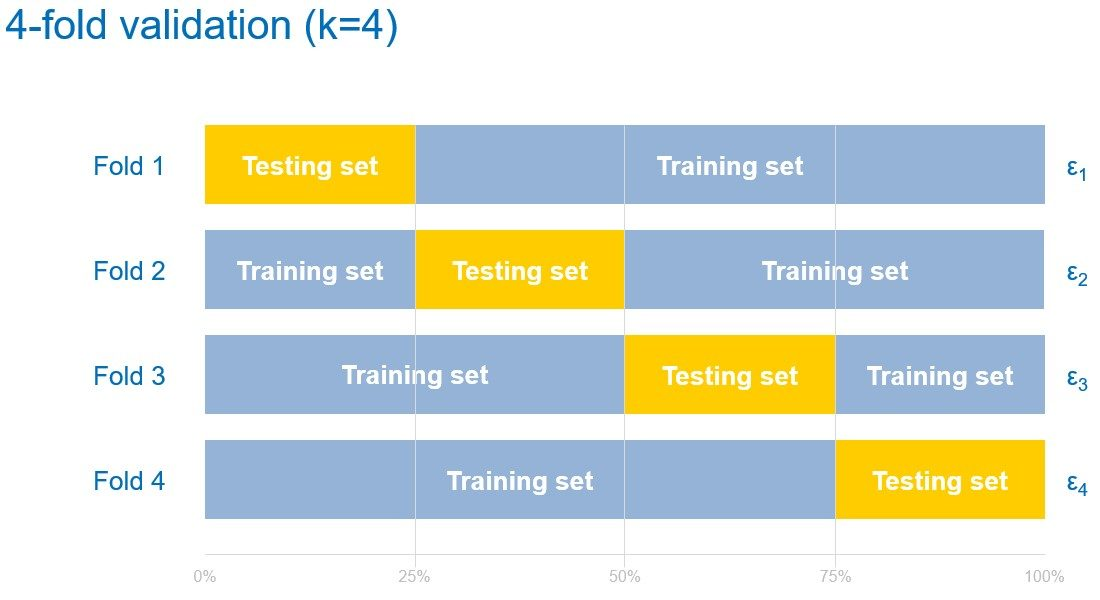

In [ ]:
'''
cross_val_score randomly splits the training set into 10 distinct subsets called folds, then it
trains and evaluates the Decision Tree model 10 times, picking a different fold for
evaluation every time and training on the other 9 folds.
'''

from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_reg, rentals_prepared, rentals_labels,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [ ]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [331.26116803 633.7659857  707.03860014 608.33655012 733.34790465
 269.98102937 770.12765709 304.35836595 344.03924918 696.96896367]
Mean: 539.9225473887707
Standard deviation: 191.50846573477216


In [ ]:
lin_scores = cross_val_score(lin_reg, rentals_prepared, rentals_labels,
                             scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [261.05060773 235.90800799 236.71190277 561.20857416 656.24222778
 218.94927151 677.79283804 210.41111288 276.16102075 678.04194636]
Mean: 401.2477509959578
Standard deviation: 200.7646440478451


In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(rentals_prepared, rentals_labels)

RandomForestRegressor(random_state=42)

In [ ]:
rentals_predictions = forest_reg.predict(rentals_prepared)
forest_mse = mean_squared_error(rentals_labels, rentals_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

np.float64(170.32466848359093)

In [ ]:
from sklearn.model_selection import cross_val_score

forest_scores = cross_val_score(forest_reg, rentals_prepared, rentals_labels,
                                scoring="neg_mean_squared_error", cv=5)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores: [267.30362349 442.40566451 518.09860083 521.96821172 525.65491865]
Mean: 455.08620384065733
Standard deviation: 98.84007509602903


In [ ]:
from sklearn.model_selection import GridSearchCV

# Extended grid. With ~2.5k rows there is not infinite signal to squeeze out,
# but it's a good chance to show several hyperparameters at once.
param_grid = [
    {
        "n_estimators":     [100, 300, 500],
        "max_features":     [4, 6, 8, "sqrt"],
        "min_samples_leaf": [1, 2, 5, 10],
    },
    {
        "bootstrap":        [False],
        "n_estimators":     [100, 300],
        "max_features":     [4, 6, 8],
        "min_samples_leaf": [2, 5],
    },
]

forest_reg = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring="neg_mean_squared_error",
                           return_train_score=True, n_jobs=-1)
grid_search.fit(rentals_prepared, rentals_labels)

GridSearch and Pipeline can be combined.

The estimator can be a parameter as well of the grid.
It is possible to access the different parameters of each estimator as we saw before.

In [ ]:

pipeline = Pipeline(steps=[('preprocessor',full_pipeline),('regressor',RandomForestRegressor(random_state=42))])

In [ ]:
'''
Now we fully exploit the pipeline: each constructor argument of our custom
transformer becomes a tunable hyperparameter. We let GridSearchCV decide
*per regressor* which engineered features to keep.

Hyperparameter paths follow the "step__substep__param" syntax:
  preprocessor                                            (ColumnTransformer)
    .num                                                  (numerical Pipeline)
      .attribs_adder                                      (CombinedAttributesAdder)
        .add_sqm_x_income    / .add_sqm_x_transport / .add_rooms_x_bath

Each flag is independent, so the search will evaluate 2*2*2 = 8 feature
subsets per regressor. Expect the linear model to like the interactions
on (they linearise the signal it can\'t see otherwise) and the random
forest to prefer them off (it discovers the same interactions via splits).
'''

params = [
    # --- Linear regression branch -----------------------------------------
    {
        "preprocessor": [full_pipeline],
        "preprocessor__num__attribs_adder__add_sqm_x_income":    [True, False],
        "preprocessor__num__attribs_adder__add_sqm_x_transport": [True, False],
        "preprocessor__num__attribs_adder__add_rooms_x_bath":    [True, False],
        "regressor": [LinearRegression()],
        "regressor__fit_intercept": [True, False],
    },
    # --- Random forest branch ---------------------------------------------
    {
        "preprocessor": [full_pipeline],
        "preprocessor__num__attribs_adder__add_sqm_x_income":    [True, False],
        "preprocessor__num__attribs_adder__add_sqm_x_transport": [True, False],
        "preprocessor__num__attribs_adder__add_rooms_x_bath":    [True, False],
        "regressor": [RandomForestRegressor(random_state=42, n_jobs=-1)],
        "regressor__n_estimators":     [100, 300],
        "regressor__max_features":     [6, 8, "sqrt"],
        "regressor__min_samples_leaf": [1, 2, 5],
    },
]

grid_search = GridSearchCV(pipeline, params, cv=3,
                           scoring="neg_mean_squared_error",
                           return_train_score=True, n_jobs=-1)
grid_search.fit(rentals, rentals_labels)

#### Exercise — extend the search to the preprocessing steps

The pipeline syntax we just used works for *any* step, not only for the engineered-features flag. As an exercise, try adding to the param grid:

1. **The imputer strategy** — `preprocessor__num__imputer__strategy` over `["mean", "median", "most_frequent"]`. Is the median really the best choice for `year_built` and `condo_fees`?
2. **The scaler choice** — replace the fixed `StandardScaler` with a tunable step and try `StandardScaler()`, `MinMaxScaler()`, and `RobustScaler()`. For tree-based models the choice is almost irrelevant; for linear regression it can matter.
3. **The encoder for `nearest_metro`** — would `OrdinalEncoder` (M1=1, M2=2, …) hurt or help compared to `OneHotEncoder`?

Each of these is a one-line addition to `params`. Re-run the grid search and inspect `grid_search.best_params_` to see what wins.

Takeaway: with a well-built `Pipeline + ColumnTransformer`, **preprocessing decisions stop being arbitrary choices and become hyperparameters you can fine-tune like any other**.

In [ ]:
grid_search.best_params_

{'preprocessor': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('attribs_adder',
                                                   CombinedAttributesAdder()),
                                                  ('std_scaler',
                                                   StandardScaler())]),
                                  ['sqm', 'rooms', 'bedrooms', 'bathrooms',
                                   'floor', 'elevator', 'year_built',
                                   'condo_fees', 'deposit_months',
                                   'distance_duomo_km', 'avg_income_eur',
                                   'transport_score']),
                                 ('cat', OneHotEncoder(handle_unknown='ignore'),
                                  ['energy_class', 'nearest_metro', 'furnishing',
     

In [ ]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('attribs_adder',
                                                                   CombinedAttributesAdder()),
                                                                  ('std_scaler',
                                                                   StandardScaler())]),
                                                  ['sqm', 'rooms', 'bedrooms',
                                                   'bathrooms', 'floor',
                                                   'elevator', 'year_built',
                                                   'condo_fees',
                                                   'deposit_months',
                                                   'distance_duomo_km',
                                                   'avg_income_eur',
                                                   'transport_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['energy_class',
                                                   'nearest_metro',
                                                   'furnishing', 'heating',
                                                   'contract_type'])])),
                ('regressor', LinearRegression())])

In [ ]:
cvres = pd.DataFrame(grid_search.cv_results_)
print(cvres.columns)
cvres['sqrt'] = np.sqrt(-cvres['mean_test_score'])
cvres.sort_values(by='sqrt',ascending=True)

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_preprocessor', 'param_regressor',
       'param_regressor__fit_intercept', 'param_regressor__min_samples_split',
       'param_regressor__n_estimators', 'params', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score', 'split0_train_score',
       'split1_train_score', 'split2_train_score', 'mean_train_score',
       'std_train_score'],
      dtype='object')


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessor,param_regressor,param_regressor__fit_intercept,param_regressor__min_samples_split,param_regressor__n_estimators,params,...,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score,sqrt
0,0.026874,0.002460,0.014027,0.000777,"ColumnTransformer(transformers=[('num',\n ...",LinearRegression(),True,NaN,NaN,{'preprocessor': ColumnTransformer(transformer...,...,-184563.567413,-205786.046799,124355.161633,1,-258450.842969,-112551.505516,-199314.109651,-190105.486045,59918.017484,453.636470
4,0.204995,0.004156,0.013755,0.000746,"ColumnTransformer(transformers=[('num',\n ...",RandomForestRegressor(random_state=42),NaN,10.0,20.0,{'preprocessor': ColumnTransformer(transformer...,...,-187711.115629,-224088.180767,124805.772722,2,-121056.951190,-49338.434818,-93215.049364,-87870.145124,29521.883394,473.379531
2,0.241894,0.001817,0.013727,0.000271,"ColumnTransformer(transformers=[('num',\n ...",RandomForestRegressor(random_state=42),NaN,5.0,20.0,{'preprocessor': ColumnTransformer(transformer...,...,-201581.490132,-228740.570592,122181.943702,3,-89477.230858,-41044.254001,-86323.525559,-72281.670140,22125.680246,478.268304
3,0.116894,0.005523,0.012825,0.001599,"ColumnTransformer(transformers=[('num',\n ...",RandomForestRegressor(random_state=42),NaN,10.0,10.0,{'preprocessor': ColumnTransformer(transformer...,...,-207829.816549,-233875.422814,125564.958292,4,-121596.474221,-51959.194953,-109136.701361,-94230.790178,30320.260631,483.606682
1,0.145566,0.015268,0.012117,0.000433,"ColumnTransformer(transformers=[('num',\n ...",RandomForestRegressor(random_state=42),NaN,5.0,10.0,{'preprocessor': ColumnTransformer(transformer...,...,-230494.192886,-240206.706047,123338.717938,5,-93812.123827,-43819.620275,-102995.497128,-80209.080410,26002.925387,490.108872


In [ ]:

grid_search.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('attribs_adder',
                                                                   CombinedAttributesAdder()),
                                                                  ('std_scaler',
                                                                   StandardScaler())]),
                                                  ['sqm', 'rooms', 'bedrooms',
                                                   'bathrooms', 'floor',
                                                   'elevator', 'year_built',
                                                   'condo_fees',
                                                   'deposit_months',
                                                   'distance_duomo_km',
                                                   'avg_income_eur',
                                                   'transport_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['energy_class',
                                                   'nearest_metro',
                                                   'furnishing', 'heating',
                                                   'contract_type'])])),
                ('regressor', LinearRegression())])

In [ ]:
'''
Once we get the best estimator we can check -- at least for some models -- the feature importance.
Such as which are the features that are __more used__ to make the predictions.
'''

best_reg = grid_search.best_estimator_["regressor"]
if not hasattr(best_reg, "feature_importances_"):
    print(
        f"Best model is {type(best_reg).__name__}; "
        "feature importances are only defined for tree-based regressors in this example."
    )
else:
    feature_importances = best_reg.feature_importances_
    feature_importances

    extra_attribs = ["sqm_per_room", "age", "bedrooms_per_room"]
    cat_encoder = full_pipeline.named_transformers_["cat"]
    cat_one_hot_attribs = []
    for col, cats in zip(cat_attribs, cat_encoder.categories_):
        cat_one_hot_attribs += [f"{col}={c}" for c in cats]
    attributes = num_attribs + extra_attribs + cat_one_hot_attribs
    sorted(zip(feature_importances, attributes), reverse=True)


Best model is LinearRegression; feature importances are only defined for tree-based regressors in this example.


## Classification

Now we prove how good we are in a classification tasks.

Given a set of drawn digits we want to predict if the image is a 5 or not.

This is a problem of BINARY CLASSIFICATION

We will study which are the quality measures that we need to take into account to improve the perfomance of our model.
 - Confusion matrix
 - Precision vs Recall
 - F1
 - ROC and AUC

In [ ]:
'''
We gathered the MNIST Dataset from the dataset available directly on scikit
'''

from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [ ]:
'''
Let's explore some property of this dataset.
'''

X, y = mnist["data"], mnist["target"]
X.shape

(70000, 784)

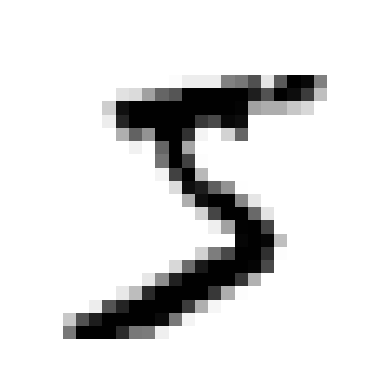

In [ ]:
'''
And how it looks like
'''

import matplotlib as mpl
import matplotlib.pyplot as plt

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
plt.axis("off")

# save_fig("some_digit_plot")
plt.show()

In [ ]:
'''
y contains the label for each image
'''

y[0]

'5'

In [ ]:
def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = mpl.cm.binary,
               interpolation="nearest")
    plt.axis("off")

In [ ]:
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size,size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap = mpl.cm.binary, **options)
    plt.axis("off")

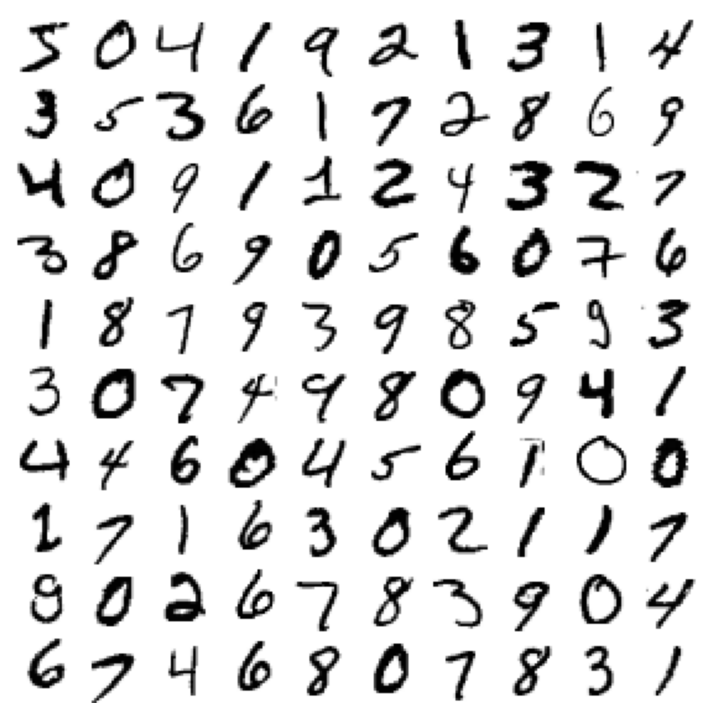

In [ ]:
'''
Some more images, just to have an idea of the content
'''
plt.figure(figsize=(9,9))
example_images = X[:100]
plot_digits(example_images, images_per_row=10)
# save_fig("more_digits_plot")
plt.show()

In [ ]:
'''
In this case, we don't use any scikit function to create training and test.
We simply take the first 60000 as training and the remaining as test.
'''

X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [ ]:
'''
As I said before, just to start and to understand some metrics tipically used
We build a binary class: it's a 5 or not.

Therefore, we will train a model to predict if a given image is a 5 or not.
'''

y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [ ]:

y_train_5

array([ True, False, False, ...,  True, False, False])

### Select the best evaluation metrics!
- Accuracy?
- Some others?

In [ ]:
'''
We try a Stochastic Gradient Descent algorithm
'''

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

```python
class sklearn.linear_model.SGDClassifier(loss='hinge', *, penalty='l2', alpha=0.0001, l1_ratio=0.15, fit_intercept=True, max_iter=1000, tol=0.001,
shuffle=True, verbose=0, epsilon=0.1, n_jobs=None, random_state=None, learning_rate='optimal', eta0=0.0, power_t=0.5, early_stopping=False,
validation_fraction=0.1, n_iter_no_change=5, class_weight=None, warm_start=False, average=False)[source]¶
```

In [ ]:
sgd_clf.predict([some_digit])

array([ True])

In [ ]:
'''
Let's try a cross validation, as we did it before.

- Notice that we use as scoring metrics the ACCURACY
'''

from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [ ]:
'''
Our classifier seems working pretty good.

And if define a classifier that predicts always false?

'''


from sklearn.base import BaseEstimator
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

In [ ]:
'''
The model accuracy is pretty high also for this simple classifier, greater than 90%

Probably the accuracy is not the right metrics to use.
'''

never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.91125, 0.90855, 0.90915])

In [ ]:
'''
We can check how our classifier predicts all the instances w.r.t. the real label

This is represented as matrix called Confusion Matrix.

Each row represents an actual class
Each column represents the predicted class
_____________
|     |     |
| TP  | FP  |
|_____|_____|
|     |     |
| FN  | TN  |
|_____|_____|

The diagonal contains the correctly labelled instances

'''

'\nWe can check how our classifier predicts all the instances w.r.t. the real label\n\nThis is represented as matrix called Confusion Matrix.\n\nEach row represents an actual class\nEach column represents the predicted class\n_____________\n|     |     |\n| TP  | FP  |\n|_____|_____|\n|     |     |\n| FN  | TN  |\n|_____|_____|\n\nThe diagonal contains the correctly labelled instances\n\n'

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

In [ ]:
y_train_perfect_predictions = y_train_5  # pretend we reached perfection
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

#### Precision and Recall


- Precision
  - accuracy of the positive predictions
  - $TP/(TP+FP)$
  - ```from sklearn.metrics import precision_score```

- Recall
  - ratio of positive instances that are correctly detected by the classifier
  - $TP/(TP+FN)$
  - also called _sensitivity_
  - ```from sklearn.metrics import recall_score```

- F1
  - The harmonic mean between Precision and Recall
  - $2 * (Precision*Recall)/(Precision+Recall)$
  - ```from sklearn.metrics import f1_score```

In [ ]:
from sklearn.metrics import precision_score, recall_score

print('Precision score: {}'.format(precision_score(y_train_5, y_train_pred)))

cm = confusion_matrix(y_train_5, y_train_pred)
print('Precision score: {}'.format(cm[1, 1] / (cm[0, 1] + cm[1, 1])))



Precision score: 0.8370879772350012
Precision score: 0.8370879772350012


In [ ]:
print('Recall score: {}'.format(recall_score(y_train_5, y_train_pred)))
print('Recall score: {}'.format(cm[1, 1] / (cm[1, 0] + cm[1, 1])))

Recall score: 0.6511713705958311
Recall score: 0.6511713705958311


In [ ]:
from sklearn.metrics import f1_score

print('F1 score: {}'.format(f1_score(y_train_5, y_train_pred)))
print('F1 score: {}'.format(cm[1, 1] / (cm[1, 1] + (cm[1, 0] + cm[0, 1]) / 2)))

F1 score: 0.7325171197343847
F1 score: 0.7325171197343847


In [ ]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [ ]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)

In [ ]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

There are cases in which for the final goal of the project is better to have a higher precision, while in others it is better to increase the recall.

In order to find a good balance between them, we will explore some techniques that can be used in your future projects:

- Precision/Recall curve
- ROC and AUC

They both use the fact that scikit classifiers
compute a score based on a _decision function_ (or predict_proba),
and if that score is greater than a threshold, it assigns the instance to the positive class, or else it assigns it to the negative class.

- Precision/Recall curve
  - Varying the threshold use to classify an instance, it plots for each value the relative precision and recall, so that we can identify the right threshold to have a certain precision (recall).

- ROC
  - true positive rate (another name for recall) against the false positive rate (FPR) . The FPR is the ratio of negative instances that are incorrectly classified as positive. It is equal to one minus the true negative rate,
which is the ratio of negative instances that are correctly classified as negative. The TNR is also called _specificity_.
  - Also called sensitivity vs specificity

- To compare two classifiers we use the Area Under the Curve (AUC)
A perfect classifier will have a ROC AUC equal to 1, whereas a purely random classifier will have a ROC AUC equal to 0.5.


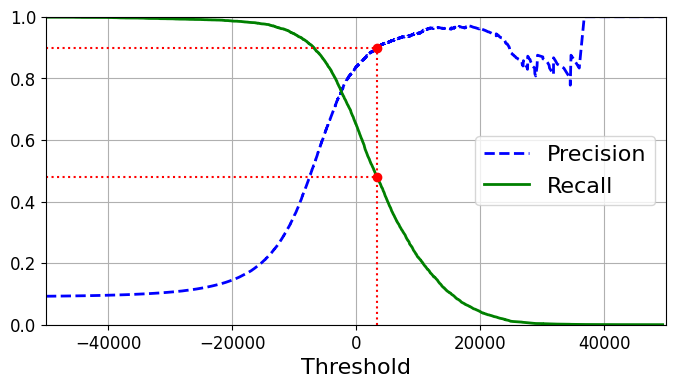

In [ ]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.legend(loc="center right", fontsize=16)
    plt.xlabel("Threshold", fontsize=16)
    plt.grid(True)
    plt.axis([-50000, 50000, 0, 1])



recall_90_precision = recalls[np.argmax(precisions >= 0.90)]
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]


plt.figure(figsize=(8, 4))
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.plot([threshold_90_precision, threshold_90_precision], [0., 0.9], "r:")
plt.plot([-50000, threshold_90_precision], [0.9, 0.9], "r:")
plt.plot([-50000, threshold_90_precision], [recall_90_precision, recall_90_precision], "r:")
plt.plot([threshold_90_precision], [0.9], "ro")
plt.plot([threshold_90_precision], [recall_90_precision], "ro")
#save_fig("precision_recall_vs_threshold_plot")
plt.show()

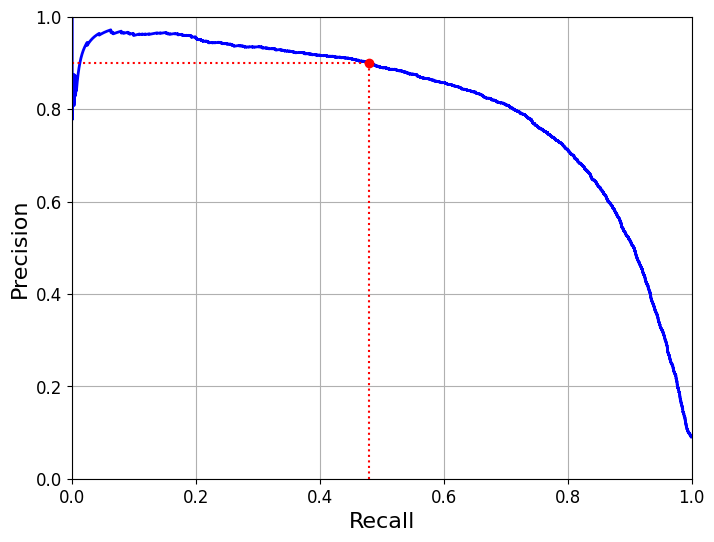

In [ ]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precisions, recalls)
plt.plot([recall_90_precision, recall_90_precision], [0., 0.9], "r:")
plt.plot([0.0, recall_90_precision], [0.9, 0.9], "r:")
plt.plot([recall_90_precision], [0.9], "ro")
# save_fig("precision_vs_recall_plot")
plt.show()

In [ ]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]

In [ ]:
y_train_pred_90 = (y_scores >= threshold_90_precision)

In [ ]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [ ]:
recall_score(y_train_5, y_train_pred_90)

0.4799852425751706

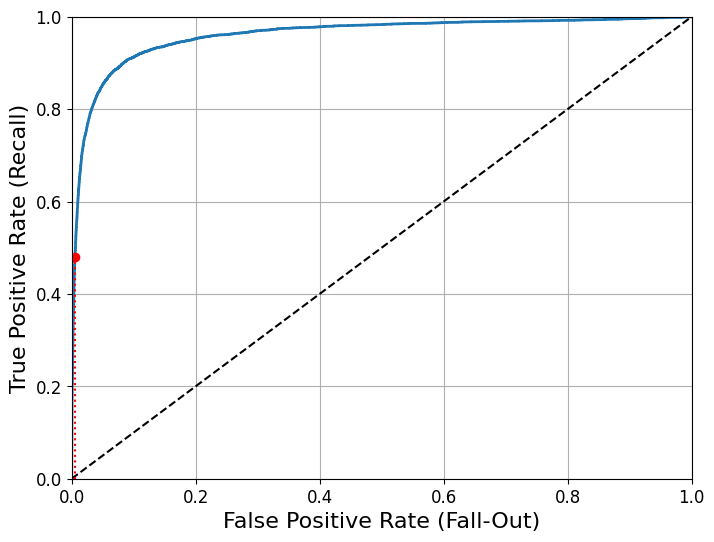

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16)
    plt.ylabel('True Positive Rate (Recall)', fontsize=16)
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_roc_curve(fpr, tpr)
fpr_90 = fpr[np.argmax(tpr >= recall_90_precision)]
plt.plot([fpr_90, fpr_90], [0., recall_90_precision], "r:")
plt.plot([0.0, fpr_90], [recall_90_precision, recall_90_precision], "r:")
plt.plot([fpr_90], [recall_90_precision], "ro")
#save_fig("roc_curve_plot")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

np.float64(0.9604938554008616)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

In [ ]:
y_scores_forest = y_probas_forest[:, 1] # score = proba of positive class
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5,y_scores_forest)

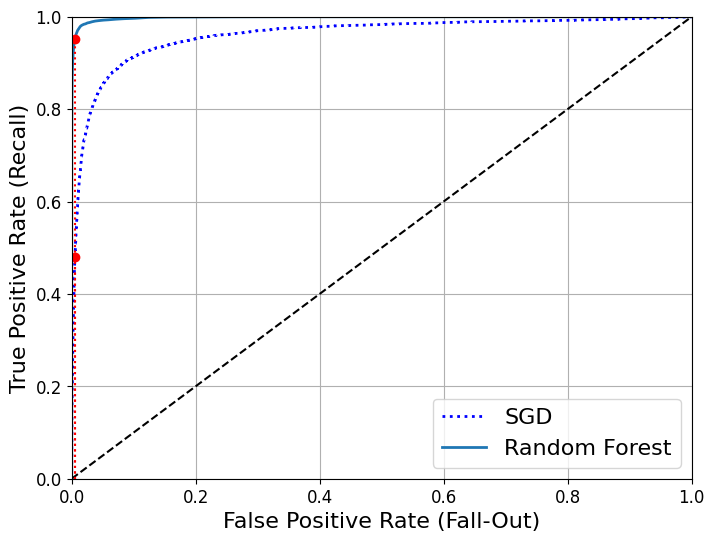

In [ ]:
recall_for_forest = tpr_forest[np.argmax(fpr_forest >= fpr_90)]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, "b:", linewidth=2, label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.plot([fpr_90, fpr_90], [0., recall_90_precision], "r:")
plt.plot([0.0, fpr_90], [recall_90_precision, recall_90_precision], "r:")
plt.plot([fpr_90], [recall_90_precision], "ro")
plt.plot([fpr_90, fpr_90], [0., recall_for_forest], "r:")
plt.plot([fpr_90], [recall_for_forest], "ro")
plt.grid(True)
plt.legend(loc="lower right", fontsize=16)
#save_fig("roc_curve_comparison_plot")
plt.show()

In [ ]:
!pip install xgboost

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from xgboost import XGBClassifier

pipeline = Pipeline(steps=[('classifier',RandomForestClassifier())])

params = [
        {
         'classifier': [GradientBoostingClassifier(random_state=42)],
         'classifier__max_depth':[10],
         'classifier__n_estimators': [10,20],
         'classifier__n_iter_no_change':[10],
         'classifier__learning_rate':[0.1,1]
        },
    {
          'classifier': [XGBClassifier(random_state=42)],
         'classifier__n_estimators': [10,20],
          'classifier__learning_rate':[0.1,1]
        },
          # {
          #  'classifier': [RandomForestClassifier(random_state=42)],
          #  'classifier__n_estimators':[10,20],
          #  'classifier__min_samples_split':[4],
          # }
]

grid_search = GridSearchCV(pipeline, params, verbose=10, n_jobs=3,scoring='roc_auc',cv=3).fit(X_train[:1000], y_train_5[:1000])


Fitting 3 folds for each of 8 candidates, totalling 24 fits


In [ ]:
grid_search.best_estimator_

Pipeline(steps=[('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=20, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
cv = pd.DataFrame(grid_search.cv_results_)

In [ ]:
cv

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier,param_classifier__learning_rate,param_classifier__max_depth,param_classifier__n_estimators,param_classifier__n_iter_no_change,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,5.953537,0.224411,0.026734,0.014250,GradientBoostingClassifier(random_state=42),0.1,10.0,10,10.0,{'classifier': GradientBoostingClassifier(rand...,0.843554,0.754326,0.875908,0.824596,0.051414,6
1,7.000603,0.159695,0.022661,0.003853,GradientBoostingClassifier(random_state=42),0.1,10.0,20,10.0,{'classifier': GradientBoostingClassifier(rand...,0.868732,0.716460,0.874752,0.819982,0.073242,7
2,3.388447,0.575547,0.018196,0.010588,GradientBoostingClassifier(random_state=42),1.0,10.0,10,10.0,{'classifier': GradientBoostingClassifier(rand...,0.838550,0.677366,0.912816,0.809577,0.098281,8
3,5.403114,2.463265,0.016974,0.009062,GradientBoostingClassifier(random_state=42),1.0,10.0,20,10.0,{'classifier': GradientBoostingClassifier(rand...,0.867242,0.711974,0.914686,0.831301,0.086571,5
4,2.030449,0.122527,0.044589,0.007594,"XGBClassifier(base_score=None, booster=None, c...",0.1,NaN,10,NaN,"{'classifier': XGBClassifier(base_score=None, ...",0.953902,0.940291,0.863586,0.919260,0.039757,4
5,2.753660,0.402519,0.043380,0.023050,"XGBClassifier(base_score=None, booster=None, c...",0.1,NaN,20,NaN,"{'classifier': XGBClassifier(base_score=None, ...",0.961887,0.949690,0.923707,0.945095,0.015922,1
6,0.694394,0.081375,0.020214,0.007512,"XGBClassifier(base_score=None, booster=None, c...",1.0,NaN,10,NaN,"{'classifier': XGBClassifier(base_score=None, ...",0.950282,0.946165,0.889219,0.928555,0.027866,3
7,0.954217,0.076631,0.021092,0.002640,"XGBClassifier(base_score=None, booster=None, c...",1.0,NaN,20,NaN,"{'classifier': XGBClassifier(base_score=None, ...",0.951986,0.941465,0.905721,0.933057,0.019801,2


Let's try our checklist on a new dataset

Titanic -- well known dataset available from Kaggle

In [ ]:
# Titanic CSVs next to the Milan data (Colab/local), or OpenML fallback when missing
candidate_titanic_dirs = [
    pathlib.Path("data/titanic"),
    pathlib.Path("../../../data/titanic"),
    DATA_DIR.parent / "titanic",
    pathlib.Path("/content/drive/Shareddrives/phd_hands_on/data/titanic"),
]
if any((d / "train.csv").exists() for d in candidate_titanic_dirs):
    TITANIC_DIR = next(d for d in candidate_titanic_dirs if (d / "train.csv").exists())
    training = pd.read_csv(TITANIC_DIR / "train.csv")
    test = pd.read_csv(TITANIC_DIR / "test.csv")
else:
    from sklearn.datasets import fetch_openml
    full = fetch_openml("titanic", version=1, as_frame=True, parser="auto").frame
    ix = np.random.default_rng(42).permutation(len(full))
    cut = int(0.8 * len(full))
    training = full.iloc[ix[:cut]].reset_index(drop=True)
    test = full.iloc[ix[cut:]].reset_index(drop=True)


In [ ]:
# train/test DataFrames are in `training` and `test`
